#Import thư viện và Data

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

In [30]:
link ='https://drive.google.com/file/d/1uoMNr2a-ciepQqdUJh8gkYQd573G0vsY/view?usp=drive_link'

# Extract the file ID from the Google Drive link
file_id = link.split('/')[-2]

# Construct the direct download URL for gdown
direct_download_url = f'https://drive.google.com/uc?id={file_id}'

# Define the local filename
output_filename = 'da_test_data.csv'

# Download the file using gdown
gdown.download(direct_download_url, output_filename, quiet=False)

# Load the downloaded CSV into a pandas DataFrame, specifying latin1 encoding
df = pd.read_csv(output_filename, encoding='latin1')

Downloading...
From (original): https://drive.google.com/uc?id=1uoMNr2a-ciepQqdUJh8gkYQd573G0vsY
From (redirected): https://drive.google.com/uc?id=1uoMNr2a-ciepQqdUJh8gkYQd573G0vsY&confirm=t&uuid=e110e116-b590-429e-8816-9178e93736be
To: /content/da_test_data.csv
100%|██████████| 106M/106M [00:00<00:00, 135MB/s] 


#Cleaning Data

In [31]:
df.head(10)

,increment_id,order_value,total_units_order,order_type,status,ship_to,warehouse,is_2h,purchase_at,actual_fulfilled,actual_pickup,actual_package,actual_outstock,actual_delivery,deliveried_by,cancelled_at,fail_delivery,delivery_deadline,reason_cancel/fail_delivery
0,1,53000,1.0,instock,canceled,H<U+1ED3> Chí Minh,2,0,2017-06-27 17:22,2017-06-27 17:22,NaN,NaN,NaN,NaN,NaN,2017-06-27 10:25,0,NaN,NaN
1,2,84000,2.0,instock,canceled,H<U+1ED3> Chí Minh,1,0,2017-06-23 12:23,NaN,NaN,NaN,NaN,NaN,NaN,2017-06-23 05:30,0,NaN,them/bot san pham
2,3,187000,3.0,backorder,canceled,H<U+1ED3> Chí Minh,1,0,2017-06-09 10:10,2017-06-14 11:34,NaN,NaN,NaN,NaN,NaN,2017-06-14 09:01,0,NaN,giao nhieu lan khong thanh cong
3,4,292000,1.0,instock,canceled,H<U+1ED3> Chí Minh,1,0,2017-06-26 17:39,2017-06-26 17:39,NaN,NaN,NaN,NaN,NaN,2017-06-27 09:13,0,NaN,giao nhieu lan khong thanh cong
4,5,0,1.0,instock,canceled,Hà N<U+1ED9>i,2,0,2017-06-10 17:50,NaN,NaN,NaN,NaN,NaN,NaN,2017-06-19 06:14,0,NaN,NaN
5,6,112000,3.0,instock,canceled,H<U+1ED3> Chí Minh,1,0,2017-06-08 13:46,2017-06-08 13:46,NaN,NaN,NaN,NaN,NaN,2017-06-08 08:12,0,NaN,thay doi thong tin don hang
6,7,388000,5.0,backorder,canceled,Hà N<U+1ED9>i,2,0,2017-06-13 16:54,NaN,NaN,NaN,NaN,NaN,NaN,2017-06-13 09:55,0,NaN,giao nhieu lan khong thanh cong
7,8,0,2.0,instock,canceled,Lâm Ð<U+1ED3>ng,1,0,2017-06-01 15:19,2017-06-01 15:20,NaN,NaN,NaN,NaN,NaN,2017-06-01 08:29,0,NaN,thay doi thong tin don hang
8,9,410000,2.0,backorder,canceled,H<U+1ED3> Chí Minh,1,0,2017-06-21 15:29,2017-06-27 20:54,2017-06-27 21:23,2017-06-28 08:07,NaN,NaN,NaN,NaN,1,NaN,NaN
9,10,22000,1.0,instock,canceled,H<U+1ED3> Chí Minh,1,0,2017-06-19 18:38,2017-06-19 18:38,NaN,NaN,NaN,NaN,NaN,2017-06-23 05:53,0,NaN,thong tin khach hang


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629064 entries, 0 to 629063
Data columns (total 19 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   increment_id                 629064 non-null  int64  
 1   order_value                  629064 non-null  int64  
 2   total_units_order            629049 non-null  float64
 3   order_type                   629062 non-null  object 
 4   status                       629064 non-null  object 
 5   ship_to                      629064 non-null  object 
 6   warehouse                    629064 non-null  int64  
 7   is_2h                        629064 non-null  int64  
 8   purchase_at                  629064 non-null  object 
 9   actual_fulfilled             569026 non-null  object 
 10  actual_pickup                526654 non-null  object 
 11  actual_package               525202 non-null  object 
 12  actual_outstock              345605 non-null  object 
 13 

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
column_date = ['purchase_at','actual_fulfilled','actual_pickup','actual_package','actual_delivery','cancelled_at','delivery_deadline']
for col in column_date:
  df[col] = pd.to_datetime(df[col])

In [35]:
df['total_units_order'].value_counts().sort_index()

,count
total_units_order,
1.0,293790
2.0,121477
3.0,52959
4.0,46409
5.0,32912
...,...
600.0,1
700.0,1
720.0,1


In [36]:
df[df['total_units_order'].isnull()]

,increment_id,order_value,total_units_order,order_type,status,ship_to,warehouse,is_2h,purchase_at,actual_fulfilled,actual_pickup,actual_package,actual_outstock,actual_delivery,deliveried_by,cancelled_at,fail_delivery,delivery_deadline,reason_cancel/fail_delivery
331627,331628,0,NaN,instock,canceled,Ð<U+1ED3>ng Tháp,1,0,2017-06-14 08:45:00,NaT,NaT,NaT,NaN,NaT,NaN,2017-07-11 10:11:00,0,2017-06-17,NaN
400647,400648,0,NaN,instock,giao_hang_thanh_cong,Ðà N<U+1EB5>ng,1,0,2017-06-15 11:28:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-21,NaN
403747,403748,0,NaN,instock,cho_in,Hà N<U+1ED9>i,2,0,2017-06-09 14:07:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-21,NaN
427844,427845,0,NaN,instock,giao_hang_thanh_cong,H<U+1ED3> Chí Minh,2,0,2017-06-08 17:16:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-22,NaN
428949,428950,139000,NaN,instock,cho_in,H<U+1ED3> Chí Minh,2,0,2017-06-09 14:02:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-22,NaN
455252,455253,0,NaN,instock,holded,H<U+1ED3> Chí Minh,2,0,2017-06-09 14:10:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-23,NaN
497881,497882,0,NaN,instock,giao_hang_thanh_cong,Hà N<U+1ED9>i,2,0,2017-06-23 14:33:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-26,NaN
497919,497920,0,NaN,instock,giao_hang_thanh_cong,H<U+1ED3> Chí Minh,2,0,2017-06-09 14:14:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-26,NaN
501025,501026,0,NaN,instock,giao_hang_thanh_cong,Qu<U+1EA3>ng Ninh,2,0,2017-06-14 11:59:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-26,NaN
551399,551400,0,NaN,instock,giao_hang_thanh_cong,H<U+1ED3> Chí Minh,2,0,2017-06-14 11:52:00,NaT,NaT,NaT,NaN,NaT,NaN,NaT,0,2017-06-28,NaN


In [37]:
print(f'{df['order_type'].value_counts()}')
df['order_type'] = df['order_type'].fillna('instock')
df['order_type'].isnull().sum()

order_type
instock      502462
backorder    111399
preorder      15201
Name: count, dtype: int64


np.int64(0)

In [38]:
df['ship_to'].value_counts().sort_index()

,count
ship_to,
An Giang,6099
B<U+1EA1>c Liêu,2203
B<U+1EAF>c Giang,3495
B<U+1EAF>c K<U+1EA1>n,400
B<U+1EAF>c Ninh,5365
...,...
Ð<U+1EAF>k Nông,1483
Ð<U+1ED3>ng Nai,17487
Ð<U+1ED3>ng Tháp,5319


In [39]:
import re

def decode_unicode_escapes(text):
    if isinstance(text, str):
        def replace_match(match):
            hex_code = match.group(1)
            return chr(int(hex_code, 16))
        return re.sub(r'<U\+(\w{4})>', replace_match, text)
    return text

df['ship_to'] = df['ship_to'].apply(decode_unicode_escapes)

df['ship_to'].value_counts().sort_index()

,count
ship_to,
An Giang,6099
Bà Rịa - Vung Tàu,7439
Bình Duong,14535
Bình Phuớc,3566
Bình Thuận,3553
...,...
Ðà Nẵng,15241
Ðắk Lắk,4417
Ðắk Nông,1483


In [40]:
print(np.sort(df['ship_to'].unique()))

['An Giang' 'Bà Rịa - Vung Tàu' 'Bình Duong' 'Bình Phuớc' 'Bình Thuận'
 'Bình Ðịnh' 'Bạc Liêu' 'Bắc Giang' 'Bắc Kạn' 'Bắc Ninh' 'Bến Tre'
 'Cao Bằng' 'Cà Mau' 'Cần Tho' 'Gia Lai' 'Hoà Bình' 'Hung Yên' 'Hà Giang'
 'Hà Nam' 'Hà Nội' 'Hà Tinh' 'Hải Duong' 'Hải Phòng' 'Hậu Giang'
 'Hồ Chí Minh' 'Khánh Hòa' 'Kiên Giang' 'Kon Tum' 'Lai Châu' 'Long An'
 'Lào Cai' 'Lâm Ðồng' 'Lạng Son' 'Nam Ðịnh' 'Nghệ An' 'Ninh Bình'
 'Ninh Thuận' 'Phú Thọ' 'Phú Yên' 'Quảng Bình' 'Quảng Nam' 'Quảng Ngãi'
 'Quảng Ninh' 'Quảng Trị' 'Son La' 'Sóc Trang' 'Thanh Hóa' 'Thái Bình'
 'Thái Nguyên' 'Thừa Thiên Huế' 'Tiền Giang' 'Trà Vinh' 'Tuyên Quang'
 'Tây Ninh' 'Vinh Long' 'Vinh Phúc' 'Yên Bái' 'Ðiện Biên' 'Ðà Nẵng'
 'Ðắk Lắk' 'Ðắk Nông' 'Ðồng Nai' 'Ðồng Tháp']


In [41]:
region = {
    'Bình Phuớc': 'Bình Phước','Bình Duong': 'Bình Dương',
    'Cần Tho': 'Cần Thơ',
    'Hoà Bình': 'Hòa Bình','Hung Yên': 'Hưng Yên','Hà Tinh': 'Hà Tĩnh','Hải Duong': 'Hải Dương',
    'Lạng Son': 'Lạng Sơn',
    'Son La': 'Sơn La','Sóc Trang': 'Sóc Trăng',
    'Vinh Long': 'Vĩnh Long','Vinh Phúc': 'Vĩnh Phúc',
    'Bà Rịa - Vung Tàu': 'Bà Rịa - Vũng Tàu'
}

# Áp dụng các thay đổi
df['ship_to'] = df['ship_to'].replace(region)
df['ship_to'] = df['ship_to'].str.replace('Ð', 'Đ', regex=False)

# Kiểm tra lại danh sách sau khi sửa
print("Danh sách sau khi đã chuẩn hóa:")
print(np.sort(df['ship_to'].unique()))

Danh sách sau khi đã chuẩn hóa:
['An Giang' 'Bà Rịa - Vũng Tàu' 'Bình Dương' 'Bình Phước' 'Bình Thuận'
 'Bình Định' 'Bạc Liêu' 'Bắc Giang' 'Bắc Kạn' 'Bắc Ninh' 'Bến Tre'
 'Cao Bằng' 'Cà Mau' 'Cần Thơ' 'Gia Lai' 'Hà Giang' 'Hà Nam' 'Hà Nội'
 'Hà Tĩnh' 'Hòa Bình' 'Hưng Yên' 'Hải Dương' 'Hải Phòng' 'Hậu Giang'
 'Hồ Chí Minh' 'Khánh Hòa' 'Kiên Giang' 'Kon Tum' 'Lai Châu' 'Long An'
 'Lào Cai' 'Lâm Đồng' 'Lạng Sơn' 'Nam Định' 'Nghệ An' 'Ninh Bình'
 'Ninh Thuận' 'Phú Thọ' 'Phú Yên' 'Quảng Bình' 'Quảng Nam' 'Quảng Ngãi'
 'Quảng Ninh' 'Quảng Trị' 'Sóc Trăng' 'Sơn La' 'Thanh Hóa' 'Thái Bình'
 'Thái Nguyên' 'Thừa Thiên Huế' 'Tiền Giang' 'Trà Vinh' 'Tuyên Quang'
 'Tây Ninh' 'Vĩnh Long' 'Vĩnh Phúc' 'Yên Bái' 'Điện Biên' 'Đà Nẵng'
 'Đắk Lắk' 'Đắk Nông' 'Đồng Nai' 'Đồng Tháp']


In [42]:
df['reason_cancel/fail_delivery'].value_counts().sort_index()

,count
reason_cancel/fail_delivery,
chuyen hoan theo yeu cau nguoi gui,1
dat don hang khac,3
dat trung,3098
doi hinh thuc thanh toan,23
giao nhieu lan khong thanh cong,30008
gop don hang,1
het hang,5
khac,30901
khach hang thay doi nhu cau,1906


In [43]:
reason_mapping = {
    # Giao hàng thất bại
    'giao nhieu lan khong thanh cong': 'Delivery Failure',
    'moi nhieu lan khong den nhan': 'Delivery Failure',
    'khach hang tu choi nhan': 'Delivery Failure',
    'khong nghe may': 'Delivery Failure',

    # Thanh toán
    'khong nhan duoc thanh toan': 'Payment Issues',
    'doi hinh thuc thanh toan': 'Payment Issues',
    'van de ve thanh toan': 'Payment Issues',

    # Khách hàng thay đổi / không còn nhu cầu
    'khach hang thay doi nhu cau': 'Customer Change',
    'khong con nhu cau': 'Customer Change',
    'doi thong tin don hang': 'Customer Change',
    'them/bot san pham': 'Customer Change',
    'tach don hang': 'Customer Change',
    'gop don hang': 'Customer Change',
    'dat trung': 'Customer Change',
    'dat don hang khac': 'Customer Change',

    # Thông tin khách hàng
    'thong tin khach hang': 'Customer Information',
    'thue bao/sai so': 'Customer Information',
    'thay doi dia chi giao hang': 'Customer Information',

    # Vận hành / hệ thống
    'chuyen hoan theo yeu cau nguoi gui': 'Operational Issues',
    'het hang': 'Operational Issues',

    # Khác
    'khac': 'Others',
    'test': 'Test'
}

df['reason_group'] = (
    df['reason_cancel/fail_delivery']
    .str.lower()
    .str.strip()
    .map(reason_mapping)
)
df['reason_group'].value_counts().sort_index()

,count
reason_group,
Customer Change,11895
Customer Information,4911
Delivery Failure,30412
Operational Issues,6
Others,30901
Payment Issues,31608
Test,468


In [44]:
df['status'].value_counts().sort_index()

,count
status,
ban_giao_doi_tac,490
canceled,123719
cho_in,145
complete,493119
dang_dong_goi,2
dang_lay_hang,144
dang_van_chuyen,953
doi_thanh_toan,162
giao_hang_thanh_cong,9999


In [45]:
status_mapping = {
    # Completed
    'complete': 'Completed',
    'giao_hang_thanh_cong': 'Completed',

    # Cancelled
    'canceled': 'Cancelled',

    # Processing
    'processing': 'Order Processing',
    'cho_in': 'Order Processing',

    # Warehouse
    'len_ke': 'Warehouse Processing',
    'dang_dong_goi': 'Warehouse Processing',

    # Pickup
    'dang_lay_hang': 'Pickup',
    'ban_giao_doi_tac': 'Pickup',

    # Shipping
    'dang_van_chuyen': 'Shipping',

    # Payment
    'doi_thanh_toan': 'Payment Pending',

    # Hold
    'holded': 'On Hold'
}

df['status_group'] = df['status'].map(status_mapping).fillna('Unknown')
df['status_group'].value_counts().sort_index()

,count
status_group,
Cancelled,123719
Completed,503118
On Hold,25
Order Processing,147
Payment Pending,162
Pickup,634
Shipping,953
Warehouse Processing,306


In [46]:
(df.loc[df['status_group']=='Completed','actual_delivery'].isna().sum())

np.int64(4484)

In [47]:
completed_reason = df[(df['status_group']=='Completed') & (df['reason_group'].notna())]
completed_reason

,increment_id,order_value,total_units_order,order_type,status,ship_to,warehouse,is_2h,purchase_at,actual_fulfilled,...,actual_package,actual_outstock,actual_delivery,deliveried_by,cancelled_at,fail_delivery,delivery_deadline,reason_cancel/fail_delivery,reason_group,status_group
178015,178016,15000,2.0,instock,complete,Hồ Chí Minh,2,0,2017-06-03 14:50:00,2017-06-08 09:58:00,...,2017-06-08 11:46:00,2017-06-13 14:04,2017-06-13 16:54:00,A4,2017-06-04 08:10:00,0,2017-06-09,khong nhan duoc thanh toan,Payment Issues,Completed
195433,195434,17000,1.0,instock,giao_hang_thanh_cong,Trà Vinh,1,0,2017-06-08 17:21:00,2017-06-12 18:44:00,...,2017-06-12 20:33:00,NaN,2017-06-14 09:25:00,A1,2017-06-09 10:40:00,0,2017-06-10,khong nhan duoc thanh toan,Payment Issues,Completed
293146,293147,99000,2.0,instock,giao_hang_thanh_cong,Khánh Hòa,1,0,2017-06-13 16:06:00,2017-06-13 16:06:00,...,2017-06-13 17:20:00,NaN,2017-07-18 17:12:00,A1,2017-07-04 05:46:00,1,2017-06-15,giao nhieu lan khong thanh cong,Delivery Failure,Completed
460997,460998,110000,5.0,instock,giao_hang_thanh_cong,Bà Rịa - Vũng Tàu,1,0,2017-06-21 13:33:00,2017-06-23 17:30:00,...,2017-06-23 17:47:00,NaN,2017-06-26 14:19:00,A3,2017-06-22 06:50:00,0,2017-06-23,khong nhan duoc thanh toan,Payment Issues,Completed
543156,543157,475000,2.0,backorder,complete,Hồ Chí Minh,1,0,2017-06-24 23:15:00,2017-06-27 11:02:00,...,2017-06-27 13:02:00,2017-06-28 13:10,2017-06-28 15:22:00,A4,2017-06-26 02:35:00,0,2017-06-27,khong nhan duoc thanh toan,Payment Issues,Completed
544333,544334,109000,3.0,instock,complete,Hà Nội,2,0,2017-06-24 23:24:00,2017-06-29 15:33:00,...,2017-06-29 17:06:00,NaN,NaT,A4,2017-06-26 02:30:00,0,2017-06-27,khong nhan duoc thanh toan,Payment Issues,Completed
548679,548680,56000,1.0,instock,complete,Hồ Chí Minh,2,0,2017-06-25 00:12:00,2017-07-01 21:37:00,...,2017-07-02 07:31:00,2017-07-05 19:00,2017-07-05 19:58:00,A4,2017-06-26 02:45:00,0,2017-06-27,khong nhan duoc thanh toan,Payment Issues,Completed
567336,567337,37000,2.0,instock,complete,Hồ Chí Minh,1,0,2017-06-27 12:07:00,2017-06-29 15:33:00,...,2017-06-29 19:44:00,2017-06-30 13:44,2017-06-30 15:34:00,A4,2017-06-28 05:25:00,0,2017-06-28,khong nhan duoc thanh toan,Payment Issues,Completed
572139,572140,460000,3.0,backorder,complete,Hồ Chí Minh,3,0,2017-06-27 12:07:00,2017-06-29 15:33:00,...,2017-06-30 09:21:00,2017-07-01 08:08,2017-07-01 09:49:00,A4,2017-06-28 05:25:00,0,2017-06-28,khong nhan duoc thanh toan,Payment Issues,Completed
618503,618504,88000,2.0,instock,complete,Hà Nội,1,0,2017-06-24 22:57:00,2017-06-29 15:33:00,...,2017-06-29 16:19:00,2017-07-04 07:23,2017-07-04 09:47:00,A4,2017-06-26 02:25:00,0,2017-07-03,khong nhan duoc thanh toan,Payment Issues,Completed


In [48]:
df['actual_delivery'].notnull().groupby(df['status_group']).count()

,actual_delivery
status_group,
Cancelled,123719
Completed,503118
On Hold,25
Order Processing,147
Payment Pending,162
Pickup,634
Shipping,953
Warehouse Processing,306


In [51]:
df[df['status_group'] == 'Cancelled']['reason_group'].isnull().sum()

np.int64(13533)

In [62]:
df.groupby('status_group').agg(
    cancelled_at_count=('cancelled_at', 'count'),
    actual_delivery_count=('actual_delivery', 'count'),
    fail_delivery_is_1=('fail_delivery', lambda x: (x == 1).sum()),
    cancelled_at_Null = ('cancelled_at',lambda x: x.isnull().sum()),
    actual_delivery_Null = ('actual_delivery',lambda x: x.isnull().sum()),
    fail_delivery_is_0=('fail_delivery', lambda x: (x == 0).sum())
)

,cancelled_at_count,actual_delivery_count,fail_delivery_is_1,cancelled_at_Null,actual_delivery_Null,fail_delivery_is_0
status_group,,,,,,
Cancelled,112354,242,21786,11365,123477,101933
Completed,11,498634,1,503107,4484,503117
On Hold,0,0,2,25,25,23
Order Processing,1,0,0,146,147,147
Payment Pending,1,0,0,161,162,162
Pickup,0,2,51,634,632,583
Shipping,1,902,4,952,51,949
Warehouse Processing,2,3,79,304,303,227


In [63]:
# 1. Thống kê mô tả cơ bản
print("Thống kê mô tả của total_units_order:")
display(df['total_units_order'].describe())

# 2. Sử dụng phương pháp IQR để tìm ngưỡng bất thường
Q1 = df['total_units_order'].quantile(0.25)
Q3 = df['total_units_order'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"\nNgưỡng trên cho giá trị bất thường (Upper Bound): {upper_bound}")

# Lọc ra các đơn hàng có số lượng sản phẩm lớn hơn ngưỡng
outliers = df[df['total_units_order'] > upper_bound]
print(f"Số lượng bản ghi bất thường: {len(outliers)}")

# Hiển thị top 10 đơn hàng có số lượng sản phẩm cao nhất
display(outliers[['increment_id','total_units_order','order_value',
                  'status_group','cancelled_at','actual_delivery']].
        sort_values(by='total_units_order', ascending=False).head(15)
      )

Thống kê mô tả của total_units_order:


,total_units_order
count,629049.000000
mean,2.910573
std,5.323639
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,1500.000000



Ngưỡng trên cho giá trị bất thường (Upper Bound): 8.5
Số lượng bản ghi bất thường: 30887


,increment_id,total_units_order,order_value,status_group,cancelled_at,actual_delivery
1689,1690,1500.0,3832500000,Completed,NaT,2017-06-01 13:38:00
103,104,1500.0,3832500000,Cancelled,2017-05-31 08:51:00,NaT
21970,21971,1000.0,2555000000,Completed,NaT,2017-06-01 15:04:00
631,632,720.0,26336000,Completed,NaT,2017-06-22 10:41:00
1870,1871,700.0,2842000000,Completed,NaT,2017-06-08 16:43:00
2590,2591,600.0,1218000000,Completed,NaT,2017-05-31 10:54:00
235368,235369,495.0,19345000,Cancelled,2017-06-13 06:23:00,NaT
309607,309608,492.0,19230000,Warehouse Processing,NaT,NaT
251217,251218,436.0,13108000,Completed,NaT,2017-06-14 10:15:00
2016,2017,420.0,147980000,Completed,NaT,2017-05-29 19:38:00


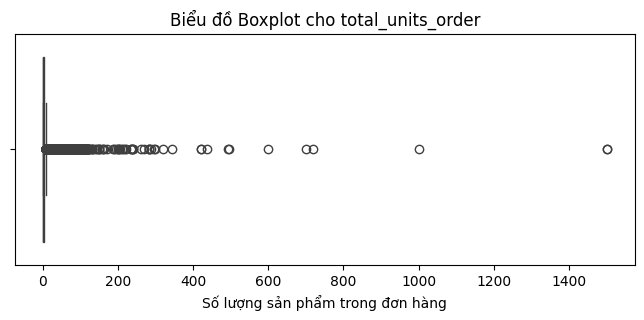

In [64]:
# 3. Vẽ biểu đồ histogram để trực quan hóa
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['total_units_order'])
plt.title('Biểu đồ Boxplot cho total_units_order')
plt.xlabel('Số lượng sản phẩm trong đơn hàng')
plt.show()

In [65]:
df[df['order_value']==0]

,increment_id,order_value,total_units_order,order_type,status,ship_to,warehouse,is_2h,purchase_at,actual_fulfilled,...,actual_package,actual_outstock,actual_delivery,deliveried_by,cancelled_at,fail_delivery,delivery_deadline,reason_cancel/fail_delivery,reason_group,status_group
4,5,0,1.0,instock,canceled,Hà Nội,2,0,2017-06-10 17:50:00,NaT,...,NaT,NaN,NaT,NaN,2017-06-19 06:14:00,0,NaT,NaN,NaN,Cancelled
7,8,0,2.0,instock,canceled,Lâm Đồng,1,0,2017-06-01 15:19:00,2017-06-01 15:20:00,...,NaT,NaN,NaT,NaN,2017-06-01 08:29:00,0,NaT,thay doi thong tin don hang,NaN,Cancelled
15,16,0,2.0,backorder,canceled,Đồng Nai,1,0,2017-06-05 17:53:00,NaT,...,NaT,NaN,NaT,NaN,2017-06-12 04:01:00,0,NaT,them/bot san pham,Customer Change,Cancelled
22,23,0,10.0,backorder,canceled,Hồ Chí Minh,1,0,2017-06-05 11:42:00,NaT,...,NaT,NaN,NaT,NaN,2017-06-05 04:43:00,0,NaT,NaN,NaN,Cancelled
23,24,0,6.0,backorder,canceled,Hồ Chí Minh,1,0,2017-06-05 11:21:00,NaT,...,NaT,NaN,NaT,NaN,2017-06-05 10:39:00,0,NaT,NaN,NaN,Cancelled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629038,629039,0,1.0,instock,dang_van_chuyen,Hồ Chí Minh,5,0,2017-06-26 11:05:00,2017-06-26 11:05:00,...,2017-06-26 15:09:00,2017-06-30 15:00,2017-06-30 16:30:00,A4,NaT,0,2017-11-13,NaN,NaN,Shipping
629046,629047,0,1.0,instock,complete,Hồ Chí Minh,3,0,2017-06-20 12:56:00,2017-06-20 13:01:00,...,2017-06-21 07:52:00,2017-06-21 12:35,2017-06-21 13:47:00,A4,NaT,0,2017-11-13,NaN,NaN,Completed
629054,629055,0,1.0,instock,complete,Hà Nội,5,0,2017-06-24 13:45:00,2017-06-24 13:54:00,...,2017-06-24 14:37:00,2017-06-27 08:23,2017-06-27 12:14:00,A4,NaT,0,2017-11-13,NaN,NaN,Completed
629060,629061,0,1.0,instock,complete,Hà Nội,5,0,2017-06-25 11:53:00,2017-06-25 12:28:00,...,2017-07-04 11:59:00,2017-07-10 13:38,2017-07-10 18:07:00,A4,NaT,0,2017-11-17,NaN,NaN,Completed


In [66]:
df[df['order_value']<0]

,increment_id,order_value,total_units_order,order_type,status,ship_to,warehouse,is_2h,purchase_at,actual_fulfilled,...,actual_package,actual_outstock,actual_delivery,deliveried_by,cancelled_at,fail_delivery,delivery_deadline,reason_cancel/fail_delivery,reason_group,status_group
1116,1117,-6000,1.0,instock,complete,Hồ Chí Minh,1,0,2017-06-14 16:06:00,2017-06-14 16:06:00,...,2017-06-14 17:34:00,NaN,2017-06-17 13:49:00,A1,NaT,0,NaT,NaN,NaN,Completed
349905,349906,-2000,2.0,instock,canceled,Bình Dương,1,0,2017-06-16 16:56:00,NaT,...,NaT,NaN,NaT,NaN,2017-06-16 09:59:00,0,2017-06-19,giao nhieu lan khong thanh cong,Delivery Failure,Cancelled
351269,351270,-2000,2.0,instock,canceled,Bình Dương,1,0,2017-06-16 16:56:00,NaT,...,NaT,NaN,NaT,NaN,2017-06-16 10:03:00,0,2017-06-19,dat trung,Customer Change,Cancelled
351923,351924,-3000,1.0,instock,canceled,Bình Dương,2,0,2017-06-16 16:59:00,NaT,...,NaT,NaN,NaT,NaN,2017-06-16 10:04:00,0,2017-06-19,khac,Others,Cancelled
362811,362812,-9000,2.0,instock,giao_hang_thanh_cong,Bình Dương,1,0,2017-06-16 16:59:00,2017-06-19 09:24:00,...,2017-06-19 16:12:00,NaN,2017-06-22 11:36:00,A1,NaT,0,2017-06-19,NaN,NaN,Completed


In [67]:
# Danh sách các cột thời gian cần kiểm tra so với purchase_at
time_cols_to_compare = [
    'actual_fulfilled',
    'actual_package',
    'actual_pickup',
    'actual_outstock',
    'actual_delivery',
    'cancelled_at',
    'delivery_deadline'
]

print("Kiểm tra có purchase_at muộn hơn các bước xử lý khác:\n")

for col in time_cols_to_compare:
    # Lọc các dòng mà purchase_at lớn hơn cột đang xét (loại bỏ giá trị NaT)
    anomalies = df[df[col].notnull() & (df['purchase_at'] > df[col])]

    count = len(anomalies)
    print(f"- So với {col}: {count} trường hợp bất thường.")

    if count > 0:
        display(anomalies[['increment_id', 'purchase_at', col, 'status_group']].head(5))
        print("-" * 30)

Kiểm tra có purchase_at muộn hơn các bước xử lý khác:

- So với actual_fulfilled: 1 trường hợp bất thường.


,increment_id,purchase_at,actual_fulfilled,status_group
2873,2874,2017-06-03 15:49:00,2017-05-04 15:49:00,Cancelled


------------------------------
- So với actual_package: 1 trường hợp bất thường.


,increment_id,purchase_at,actual_package,status_group
2873,2874,2017-06-03 15:49:00,2017-05-04 19:22:00,Cancelled


------------------------------
- So với actual_pickup: 1 trường hợp bất thường.


...

------------------------------
- So với cancelled_at: 39252 trường hợp bất thường.


,increment_id,purchase_at,cancelled_at,status_group
0,1,2017-06-27 17:22:00,2017-06-27 10:25:00,Cancelled
1,2,2017-06-23 12:23:00,2017-06-23 05:30:00,Cancelled
5,6,2017-06-08 13:46:00,2017-06-08 08:12:00,Cancelled
6,7,2017-06-13 16:54:00,2017-06-13 09:55:00,Cancelled
7,8,2017-06-01 15:19:00,2017-06-01 08:29:00,Cancelled


------------------------------
- So với delivery_deadline: 52852 trường hợp bất thường.


,increment_id,purchase_at,delivery_deadline,status_group
2873,2874,2017-06-03 15:49:00,2017-05-06,Cancelled
2874,2875,2017-05-31 10:27:00,2017-05-17,Completed
2875,2876,2017-05-29 11:39:00,2017-05-18,Completed
2876,2877,2017-06-06 11:02:00,2017-05-20,Cancelled
2877,2878,2017-06-13 15:18:00,2017-05-20,Cancelled


------------------------------


In [68]:
df['deliveried_by'].isnull().sum()
df['deliveried_by'] = df['deliveried_by'].fillna('Unknow')

#Bổ sung các trường thông tin

In [52]:
df_copy = df.copy()

In [53]:
# Fill NaN in 'reason_group' with 'Unknown' với điều kiện
con_fail_delivery = df_copy['fail_delivery'] == 1
con_cancelled_status = df_copy['status_group'] == 'Cancelled'

# Apply 'Unknown' to reason_group where it's NaN AND either condition is met
df_copy.loc[
    df_copy['reason_group'].isna() & (con_fail_delivery | con_cancelled_status),
    'reason_group'
] = 'Unknown'
df_copy['reason_group'].value_counts().sort_index()

,count
reason_group,
Customer Change,11895
Customer Information,4911
Delivery Failure,30412
Operational Issues,6
Others,30901
Payment Issues,31608
Test,468
Unknown,13669


In [54]:
# Ghi chú các cột: lỗi thời gian, Status is 'Completed' AND cancelled_at is not null, reason_group is 'Test', order_value <0
df_copy['data_quality_issue'] = 'OK'
df_copy.loc[df_copy['purchase_at'] > df_copy['cancelled_at'], 'data_quality_issue'] = 'Purchase after Cancel'
df_copy.loc[df_copy['purchase_at'] > df_copy['delivery_deadline'], 'data_quality_issue'] = 'Purchase after Deadline'
df_copy.loc[df_copy['purchase_at'] > df_copy['actual_delivery'], 'data_quality_issue'] = 'Purchase after Delivery'
df_copy.loc[(df_copy['status_group'] == 'Completed') & (df_copy['cancelled_at'].notna()), 'data_quality_issue'] = 'Completed but Cancelled'
df_copy.loc[df_copy['reason_group'] == 'Test', 'data_quality_issue'] = 'Reason Group Test'
df_copy.loc[df_copy['order_value'] < 0, 'data_quality_issue'] = 'Negative Order Value'

In [55]:
datetime_columns = [
    'purchase_at',
    'actual_fulfilled',
    'actual_package',
    'actual_pickup',
    'actual_outstock',
    'actual_delivery',
    'cancelled_at',
    'delivery_deadline'
]

# Ensure all specified columns are converted to datetime objects
for col in datetime_columns:
    # Using errors='coerce' will turn unparseable dates into NaT (Not a Time)
    df_copy[col] = pd.to_datetime(df_copy[col], errors='coerce')

print("Năm có trong các cột thời gian:")
for col in datetime_columns:
    # Extract year, drop NaT values, and find unique years
    unique_years = df_copy[col].dt.year.dropna().unique()
    # Sort the unique years for better readability
    unique_years = np.sort(unique_years)
    print(f"- {col}: {unique_years}")

Năm có trong các cột thời gian:
- purchase_at: [2017]
- actual_fulfilled: [2017.]
- actual_package: [2017.]
- actual_pickup: [2017.]
- actual_outstock: [2017.]
- actual_delivery: [2006. 2007. 2017.]
- cancelled_at: [2017.]
- delivery_deadline: [2017. 2018.]


In [56]:
# Tìm những dòng có năm của actual_delivery: 2006, 2007
df_copy[(df_copy['actual_delivery'].dt.year == 2006) | (df_copy['actual_delivery'].dt.year == 2007)]

,increment_id,order_value,total_units_order,order_type,status,ship_to,warehouse,is_2h,purchase_at,actual_fulfilled,...,actual_outstock,actual_delivery,deliveried_by,cancelled_at,fail_delivery,delivery_deadline,reason_cancel/fail_delivery,reason_group,status_group,data_quality_issue
500,501,8043000,2.0,instock,complete,Hà Nội,2,0,2017-05-29 17:21:00,2017-05-29 17:21:00,...,2017-05-31 11:13:00,2006-04-14 02:33:00,A2,NaT,0,NaT,NaN,NaN,Completed,Purchase after Delivery
16779,16780,81000,1.0,instock,complete,Bình Định,1,0,2017-05-29 11:49:00,2017-05-29 11:49:00,...,2017-06-01 10:07:00,2006-03-15 05:27:00,A2,NaT,0,2017-05-31,NaN,NaN,Completed,Purchase after Delivery
47658,47659,96000,1.0,instock,complete,Đà Nẵng,2,0,2017-05-29 12:17:00,2017-05-29 12:17:00,...,2017-05-31 09:16:00,2006-03-15 09:14:00,A2,NaT,0,2017-06-02,NaN,NaN,Completed,Purchase after Delivery
48028,48029,699000,2.0,backorder,complete,Cao Bằng,1,0,2017-05-29 12:09:00,2017-06-02 10:10:00,...,2017-06-07 10:31:00,2006-10-15 09:19:00,A2,NaT,0,2017-06-02,NaN,NaN,Completed,Purchase after Delivery
48456,48457,56000,1.0,instock,complete,Đà Nẵng,2,0,2017-05-29 13:47:00,2017-05-29 13:48:00,...,2017-05-31 09:16:00,2006-03-15 09:16:00,A2,NaT,0,2017-06-02,NaN,NaN,Completed,Purchase after Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
614694,614695,59000,2.0,instock,complete,Quảng Bình,2,0,2017-06-27 18:00:00,2017-06-27 18:01:00,...,2017-06-30 16:25:00,2007-02-13 11:23:00,A2,NaT,0,2017-07-03,NaN,NaN,Completed,Purchase after Delivery
614963,614964,0,3.0,instock,complete,Quảng Bình,2,0,2017-06-27 12:38:00,2017-06-27 12:39:00,...,2017-06-30 16:25:00,2007-02-13 09:22:00,A2,NaT,0,2017-07-03,NaN,NaN,Completed,Purchase after Delivery
615205,615206,184000,8.0,instock,complete,Thừa Thiên Huế,2,0,2017-06-27 18:11:00,2017-06-27 18:11:00,...,2017-06-30 16:25:00,2007-02-13 10:27:00,A2,NaT,0,2017-07-03,NaN,NaN,Completed,Purchase after Delivery
615410,615411,123000,4.0,instock,complete,Quảng Ngãi,2,0,2017-06-27 17:06:00,2017-06-27 17:06:00,...,2017-06-30 16:25:00,2007-02-13 01:18:00,A2,NaT,0,2017-07-03,NaN,NaN,Completed,Purchase after Delivery


In [57]:
# Chỉnh những dòng có năm của actual_delivery: 2006, 2007 thành 2017
def correct_delivery_year(dt):
    if pd.isna(dt):
        return dt
    if dt.year in [2006, 2007]:
        return dt.replace(year=2017)
    return dt

df_copy['actual_delivery'] = df_copy['actual_delivery'].apply(correct_delivery_year)

In [58]:
# Lead time toàn trình (purchase -> delivery)
df_copy['lead_time'] = (df_copy['actual_delivery'] - df_copy['purchase_at']).dt.total_seconds() / 3600

# Lead time từng bước trong pipeline: purchase -> verify -> pick -> pack -> dispatch -> deliver
df_copy['time_to_fulfill'] = (df_copy['actual_fulfilled'] - df_copy['purchase_at']).dt.total_seconds() / 3600
df_copy['time_to_pickup']  = (df_copy['actual_pickup'] - df_copy['actual_fulfilled']).dt.total_seconds() / 3600
df_copy['time_to_package'] = (df_copy['actual_package'] - df_copy['actual_pickup']).dt.total_seconds() / 3600
df_copy['time_to_deliver']  = (df_copy['actual_delivery'] - df_copy['actual_package']).dt.total_seconds() / 3600

# On-time delivery flag (so với delivery_deadline) cho 'Completed' orders
df_copy['is_on_time'] = pd.NA
completed_orders_mask = (df_copy['status_group'] == 'Completed')
df_copy.loc[completed_orders_mask, 'is_on_time'] = (
    df_copy.loc[completed_orders_mask, 'actual_delivery'] <= df_copy.loc[completed_orders_mask, 'delivery_deadline']
)

# Lead time bucket (để trả lời câu hỏi "2 giờ, 1 ngày, 2 ngày...")
def bucket_lead_time(hours):
    if pd.isna(hours):
        return pd.NA
    if 0 < hours <= 2: return '≤2h'
    elif hours <= 24: return '≤1 ngày'
    elif hours <= 48: return '≤2 ngày'
    elif hours <= 72: return '≤3 ngày'
    else: return '>3 ngày'

df_copy['lead_time_bucket'] = df_copy['lead_time'].apply(bucket_lead_time)

In [59]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629064 entries, 0 to 629063
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   increment_id                 629064 non-null  int64         
 1   order_value                  629064 non-null  int64         
 2   total_units_order            629049 non-null  float64       
 3   order_type                   629064 non-null  object        
 4   status                       629064 non-null  object        
 5   ship_to                      629064 non-null  object        
 6   warehouse                    629064 non-null  int64         
 7   is_2h                        629064 non-null  int64         
 8   purchase_at                  629064 non-null  datetime64[ns]
 9   actual_fulfilled             569026 non-null  datetime64[ns]
 10  actual_pickup                526654 non-null  datetime64[ns]
 11  actual_package            

In [60]:
df_copy.describe()

,increment_id,order_value,total_units_order,warehouse,is_2h,purchase_at,actual_fulfilled,actual_pickup,actual_package,actual_outstock,actual_delivery,cancelled_at,fail_delivery,delivery_deadline,lead_time,time_to_fulfill,time_to_pickup,time_to_package,time_to_deliver
count,629064.000000,6.290640e+05,629049.000000,629064.000000,629064.000000,629064,569026,526654,525202,345605,499783,112370,629064.00000,626191,499783.000000,569026.000000,526629.000000,525090.000000,499775.000000
mean,314532.500000,4.842730e+05,2.910573,1.608868,0.098705,2017-06-13 04:25:36.482011648,2017-06-13 11:28:48.573421312,2017-06-13 16:51:33.586985728,2017-06-13 17:40:08.832830464,2017-06-14 22:10:35.331259648,2017-06-15 13:46:54.695497216,2017-06-15 00:02:05.568034048,0.03485,2017-06-16 10:45:23.954831872,61.501242,7.590810,5.608303,0.844647,47.363423
min,1.000000,-9.000000e+03,1.000000,1.000000,0.000000,2017-05-28 00:00:00,2017-05-04 15:49:00,2017-05-04 18:11:00,2017-05-04 19:22:00,2017-05-28 07:48:00,2017-01-15 01:59:00,2017-05-13 06:10:00,0.00000,2017-05-06 00:00:00,-3928.216667,-720.000000,0.000000,0.000000,-3928.816667
25%,157266.750000,7.000000e+04,1.000000,1.000000,0.000000,2017-06-05 19:12:00,2017-06-06 09:23:00,2017-06-06 11:39:00,2017-06-06 13:04:00,2017-06-07 12:25:00,2017-06-08 08:04:00,2017-06-07 08:19:00,0.00000,2017-06-08 00:00:00,25.433333,0.000000,0.716667,0.083333,21.383333
50%,314532.500000,1.300000e+05,2.000000,1.000000,0.000000,2017-06-13 11:57:00,2017-06-13 15:51:00,2017-06-13 18:24:00,2017-06-13 18:52:00,2017-06-14 15:56:00,2017-06-15 12:40:00,2017-06-15 04:28:00,0.00000,2017-06-16 00:00:00,47.166667,0.000000,1.566667,0.166667,39.816667
75%,471798.250000,2.440000e+05,4.000000,2.000000,0.000000,2017-06-20 18:29:00,2017-06-20 22:18:00,2017-06-21 09:04:00,2017-06-21 09:40:00,2017-06-22 08:04:00,2017-06-22 16:04:00,2017-06-22 09:02:00,0.00000,2017-06-23 00:00:00,77.950000,0.016667,7.900000,0.550000,66.716667
max,629064.000000,3.832500e+09,1500.000000,5.000000,1.000000,2017-06-27 23:59:00,2017-07-20 13:16:00,2017-07-21 17:34:00,2017-07-21 19:54:00,2017-07-26 15:45:00,2017-10-15 10:31:00,2017-07-26 02:52:00,1.00000,2018-02-07 00:00:00,3333.166667,812.416667,579.916667,216.100000,3285.916667
std,181595.279206,8.861853e+06,5.323639,0.921750,0.298266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.18340,NaN,65.894029,34.264145,11.599208,2.703876,53.660616


In [61]:
df_copy.to_csv('da_test_data_clean.csv', index=False)